# Uncertainty diagnostics for exported results

This notebook reads exported `.npy` prediction-interval results from `result/<project>/<model>/<dataset>/`. It accepts either a concrete result file or a project/model/dataset selector, so figures can be regenerated for any experiment.

The exporter stores four components. Flow CQR uses `(lower, point, upper, label)`, while OD-CQR, ACI, and ZeroCQR use `(point, lower, upper, label)`. The loader checks both conventions automatically; set `component_order` explicitly if a non-standard export is used.

In [24]:
from dataclasses import dataclass
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Match the typography and compact, publication-oriented styling in result.ipynb.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

RESULT_ROOT = Path('/home/dy23a.fsu/st/result')
FIGURE_DIR = Path('/home/dy23a.fsu/st/result/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Preferred: give exact files (one or more). Paths may be absolute or relative to RESULT_ROOT.
RESULT_PATHS = [
    # 'Chi_OD_Calibration/pdr_reg_post/chicago_od_15min_bike/pdr_reg_post-chicago_od_15min_bike-zero_cqr_8bin-res.npy',
]

# Alternative: selectors resolve a single file within result/<project>/<model>/<dataset>.
# `pattern` can target a calibration variant; `latest=True` then selects its newest export.
SELECTIONS = [
    dict(project='NYC_OD', model='PDR_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='PDR'),
    
    # Sparse-aware post-hoc calibration of the PDR_REG point forecast.
    dict(project='NYC_OD', model='PDR_REG_POST', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*zero_cqr_8bin_res*.npy', label='ZeroCQR (PDR)'),

    # Representative graph / OD-learning baselines, all with the same split-CQR protocol.
    dict(project='NYC_OD', model='AGCRN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='AGCRN'),
    dict(project='NYC_OD', model='STGCN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='STGCN'),
    dict(project='NYC_OD', model='GWNET_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='GWNET'),
    dict(project='NYC_OD', model='GMEL_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='GMEL'),
]

# Keep notebook responsive for large OD tensors. Set None to use all valid cells.
MAX_SAMPLES = 500_000  # six-model comparison; fixed shared random sample for responsive figures
RANDOM_SEED = 2026
SOURCE_NOMINAL_COVERAGE = 0.95  # must match the coverage used to export the saved intervals
COMPONENT_ORDER = 'auto'        # 'auto', 'flow_cqr', or 'od_cqr'
SAVE_FIGURES = False


In [25]:
def discover_results(root=RESULT_ROOT):
    """Return every exported array with its project/model/dataset location."""
    rows = []
    for path in sorted(root.glob('*/*/*/*res*.npy')):
        rel = path.relative_to(root)
        rows.append(dict(project=rel.parts[0], model=rel.parts[1], dataset=rel.parts[2],
                         file=path.name, path=str(path), modified=pd.Timestamp(path.stat().st_mtime, unit='s')))
    return pd.DataFrame(rows)

def resolve_selection(selection, root=RESULT_ROOT):
    directory = root / selection['project'] / selection['model'] / selection['dataset']
    pattern = selection.get('pattern', '*res*.npy')
    matches = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f'No result matched {directory / pattern}')
    return matches[-1], selection.get('label', f"{selection['model']} | {selection['dataset']}")

def requested_paths():
    chosen = []
    for item in RESULT_PATHS:
        path = Path(item)
        path = path if path.is_absolute() else RESULT_ROOT / path
        if not path.exists():
            raise FileNotFoundError(path)
        chosen.append((path, path.stem.replace('-res', '')))
    chosen.extend(resolve_selection(s) for s in SELECTIONS)
    if not chosen:
        raise ValueError('Add at least one path to RESULT_PATHS or one entry to SELECTIONS.')
    return chosen

@dataclass
class IntervalData:
    label: str
    path: Path
    point: np.ndarray
    lower: np.ndarray
    upper: np.ndarray
    target: np.ndarray
    horizon: np.ndarray
    order: str

def _order_score(point, lower, upper):
    finite = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper)
    if not finite.any():
        return -np.inf
    return np.mean((lower[finite] <= point[finite]) & (point[finite] <= upper[finite]))

def load_interval_result(path, label=None, component_order=COMPONENT_ORDER, max_samples=MAX_SAMPLES, seed=RANDOM_SEED):
    """Load a bounded random sample without materializing a large OD result tensor."""
    raw = np.load(path, mmap_mode='r')
    if raw.ndim < 2 or raw.shape[0] < 4:
        raise ValueError(f'{path.name} is not a four-component interval export; found shape {raw.shape}.')
    total = int(np.prod(raw.shape[1:]))
    rng = np.random.default_rng(seed)
    take = total if max_samples is None else min(total, int(max_samples))
    flat_idx = np.arange(total) if take == total else rng.choice(total, size=take, replace=False)

    # Compare the two exporter conventions using a small sampled slice.
    probe = flat_idx[:min(10_000, len(flat_idx))]
    c0, c1, c2 = (raw[i].reshape(-1)[probe] for i in range(3))
    candidates = {'flow_cqr': (c1, c0, c2), 'od_cqr': (c0, c1, c2)}
    if component_order == 'auto':
        component_order = max(candidates, key=lambda key: _order_score(*candidates[key]))
    if component_order not in candidates:
        raise ValueError("component_order must be 'auto', 'flow_cqr', or 'od_cqr'.")
    point_i, lower_i, upper_i = {'flow_cqr': (1, 0, 2), 'od_cqr': (0, 1, 2)}[component_order]
    point = np.asarray(raw[point_i].reshape(-1)[flat_idx], dtype=float)
    lower = np.asarray(raw[lower_i].reshape(-1)[flat_idx], dtype=float)
    upper = np.asarray(raw[upper_i].reshape(-1)[flat_idx], dtype=float)
    target = np.asarray(raw[3].reshape(-1)[flat_idx], dtype=float)
    valid = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper) & np.isfinite(target) & (upper >= lower)
    # In C-order, horizon advances after all later dimensions have been enumerated.
    horizon_size = raw.shape[2] if raw.ndim >= 3 else 1
    stride_after_horizon = int(np.prod(raw.shape[3:])) if raw.ndim >= 4 else 1
    horizon = (flat_idx // stride_after_horizon) % horizon_size
    return IntervalData(label or path.stem, Path(path), point[valid], lower[valid], upper[valid],
                        target[valid], horizon[valid], component_order)

available = discover_results()
print(f'Found {len(available)} exported .npy result files under {RESULT_ROOT}.')
available.head(10)


Found 1803 exported .npy result files under /home/dy23a.fsu/st/result.


,project,model,dataset,file,path,modified
0,Chi_OD,AGCRN_OD,chicago_od_15min_bike,AGCRN_OD-chicago_od_15min_bike-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-19 09:14:23
1,Chi_OD,AGCRN_OD,chicago_od_15min_taxi,AGCRN_OD-chicago_od_15min_taxi-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-17 21:35:58
2,Chi_OD,AGCRN_OD,chicago_od_15min_tnp,AGCRN_OD-chicago_od_15min_tnp-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-18 20:15:42
3,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 07:57:38
4,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 12:54:22
5,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-22 07:20:23
6,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 07:57:24
7,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 12:54:06
8,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-22 07:20:09
9,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_cqr_od_c...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-20 12:36:22


In [26]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
MARKERS = ['^', 'o', 's', 'D', 'v', 'P']

def style_axis(ax, xlabel, ylabel, xpercent=False, ypercent=False):
    ax.set_xlabel(xlabel, fontsize=22, fontweight='bold', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=22, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=7, width=1.4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.grid(True, linestyle='--', linewidth=0.9, alpha=0.35, zorder=0)
    if xpercent:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    if ypercent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

def interval_score(lower, upper, target, alpha=1 - SOURCE_NOMINAL_COVERAGE):
    width = upper - lower
    return width + (2 / alpha) * np.maximum(lower - target, 0) + (2 / alpha) * np.maximum(target - upper, 0)

def calibration_curve(data, targets=np.linspace(.05, .99, 20)):
    center, half_width = (data.lower + data.upper) / 2, (data.upper - data.lower) / 2
    empirical = [np.mean((data.target >= center - half_width * (c / SOURCE_NOMINAL_COVERAGE)) &
                         (data.target <= center + half_width * (c / SOURCE_NOMINAL_COVERAGE))) for c in targets]
    return targets, np.asarray(empirical)

def selective_risk(data, coverages=np.linspace(.02, 1, 50)):
    mae = np.abs(data.target - data.point)
    ranking = np.argsort(interval_score(data.lower, data.upper, data.target))
    risk = [mae[ranking[:max(1, math.ceil(c * len(mae)))]].mean() for c in coverages]
    return coverages, np.asarray(risk), mae.mean()

def width_strata(data, bins=10):
    width = data.upper - data.lower
    edges = np.quantile(width, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    group = np.clip(np.digitize(width, edges[1:-1], right=True), 0, len(edges) - 2)
    x = np.arange(len(edges) - 1) + 1
    cov = np.array([np.mean((data.target[group == j] >= data.lower[group == j]) & (data.target[group == j] <= data.upper[group == j])) for j in range(len(x))])
    mae = np.array([np.mean(np.abs(data.target[group == j] - data.point[group == j])) for j in range(len(x))])
    return x, cov, mae

def method_style(label, index):
    """Keep proposed methods visually identifiable without changing any data."""
    name = label.lower()
    if 'zero' in name:
        return dict(color='#c51b7d', marker='D', zorder=8)  # ZeroCQR
    if 'pdr' in name:
        return dict(color='#54278f', marker='^', zorder=7)  # PDR family
    return dict(color=COLORS[index % len(COLORS)], marker=MARKERS[index % len(MARKERS)], zorder=3 + index)

def covered(lower, upper, target):
    return (target >= lower) & (target <= upper)

SPARSITY_STRATA = ('0', '1', '2–3', '≥4')

def demand_groups(data):
    # Fixed, interpretable bins shared by every model; no examples are discarded.
    y = data.target
    return [('0', y <= .5), ('1', (y > .5) & (y <= 1.5)),
            ('2–3', (y > 1.5) & (y <= 3.5)), ('≥4', y > 3.5)]

def uniform_interval_crps(lower, upper, target):
    """CRPS of the uniform distribution implied by a saved interval.

    A full predictive-distribution CRPS requires exported quantiles or distributional
    parameters. This reproducible proxy uses only the saved interval endpoints.
    """
    width = upper - lower
    safe_width = np.maximum(width, np.finfo(float).eps)
    inside = ((target - lower) ** 2 + (upper - target) ** 2) / (2 * safe_width)
    outside_low = (lower + upper) / 2 - target
    outside_high = target - (lower + upper) / 2
    expected_abs_error = np.where(target < lower, outside_low, np.where(target > upper, outside_high, inside))
    return np.where(width > 0, expected_abs_error - width / 6, np.abs(target - lower))

def zero_detection_metrics(data, zero_threshold=.5):
    true_zero = data.target <= zero_threshold
    predicted_zero = data.point <= zero_threshold
    tp = np.sum(true_zero & predicted_zero)
    fp = np.sum(~true_zero & predicted_zero)
    fn = np.sum(true_zero & ~predicted_zero)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)  # true-zero detection rate
    f1 = 2 * precision * recall / max(precision + recall, np.finfo(float).eps)
    return dict(zero_f1=f1, true_zero_rate=recall, zero_precision=precision, true_zero_prevalence=true_zero.mean())


In [27]:
def plot_empirical_vs_target(datasets):
    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    ax.plot([0, 1], [0, 1], '--', color='#666666', lw=2.5, label='Ideal calibration', zorder=1)
    for i, data in enumerate(datasets):
        x, y = calibration_curve(data)
        style = method_style(data.label, i)
        ax.plot(x, y,
                markerfacecolor='white', markeredgewidth=1.5, markevery=2, ms=7, lw=3.2,
                label=data.label, **style)
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=np.linspace(0, 1, 6), yticks=np.linspace(0, 1, 6))
    style_axis(ax, 'Target Coverage', 'Empirical Coverage')
    ax.legend(fontsize=13, loc='lower right', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_selective_regression(datasets):
    fig, ax = plt.subplots(figsize=(6.7, 5.4))
    for i, data in enumerate(datasets):
        x, risk, nonselective = selective_risk(data)
        style = method_style(data.label, i)
        ax.plot(x, risk, markerfacecolor='white', markeredgewidth=1.4, markevery=5, ms=7, lw=3.2,
                label=f'{data.label}: IS-guided', **style)
        ax.axhline(nonselective, color=style['color'], ls='--', lw=1.8, alpha=.75, label=f'{data.label}: non-selective')
    ax.set(xlim=(0, 1), xticks=np.linspace(0, 1, 6))
    style_axis(ax, 'Coverage retained', 'Risk (MAE)', xpercent=True)
    ax.legend(fontsize=11.5, loc='upper left', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_conditional_diagnostics(datasets):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
    for i, data in enumerate(datasets):
        x, coverage, mae = width_strata(data)
        kwargs = dict(**method_style(data.label, i),
                      markerfacecolor='white', markeredgewidth=1.3, ms=6.5, lw=2.8, label=data.label)
        axes[0].plot(x, coverage, **kwargs)
        axes[1].plot(x, mae, **kwargs)
    axes[0].axhline(SOURCE_NOMINAL_COVERAGE, color='#555555', ls='--', lw=2, label='Nominal coverage')
    for ax in axes:
        ax.set_xticks(np.arange(1, 11, 2))
        ax.set_xlim(.7, 10.3)
    axes[0].set_ylim(0, 1.03)
    style_axis(axes[0], 'Interval-width decile (narrow → wide)', 'Empirical Coverage', ypercent=True)
    style_axis(axes[1], 'Interval-width decile (narrow → wide)', 'MAE')
    axes[0].legend(fontsize=11.5, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_horizon_diagnostics(datasets):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))
    for i, data in enumerate(datasets):
        h = np.unique(data.horizon)
        coverage = [np.mean((data.target[data.horizon == k] >= data.lower[data.horizon == k]) & (data.target[data.horizon == k] <= data.upper[data.horizon == k])) for k in h]
        mae = [np.mean(np.abs(data.target[data.horizon == k] - data.point[data.horizon == k])) for k in h]
        kwargs = dict(**method_style(data.label, i), markerfacecolor='white', markeredgewidth=1.3, ms=6.5, lw=2.8, label=data.label)
        axes[0].plot(h + 1, coverage, **kwargs)
        axes[1].plot(h + 1, mae, **kwargs)
    axes[0].axhline(SOURCE_NOMINAL_COVERAGE, color='#555555', ls='--', lw=2, label='Nominal coverage')
    style_axis(axes[0], 'Forecast horizon', 'Empirical Coverage', ypercent=True)
    style_axis(axes[1], 'Forecast horizon', 'MAE')
    axes[0].legend(fontsize=11.5, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_proper_score_comparison(datasets):
    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    for i, data in enumerate(datasets):
        style = method_style(data.label, i)
        is_mean = np.mean(interval_score(data.lower, data.upper, data.target))
        crps_mean = np.mean(uniform_interval_crps(data.lower, data.upper, data.target))
        ax.scatter(is_mean, crps_mean, s=125, facecolor='white', linewidth=2.2,
                   edgecolor=style['color'], marker=style['marker'], zorder=style['zorder'])
        ax.annotate(data.label, (is_mean, crps_mean), xytext=(6, 6), textcoords='offset points', fontsize=11)
    style_axis(ax, 'Mean interval score ↓', 'Mean uniform-interval CRPS ↓')
    fig.tight_layout()
    return fig

def plot_zero_detection(datasets):
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    x = np.arange(len(datasets))
    f1 = [zero_detection_metrics(d)['zero_f1'] for d in datasets]
    tzr = [zero_detection_metrics(d)['true_zero_rate'] for d in datasets]
    width = .36
    ax.bar(x - width / 2, f1, width, color='#54278f', label='Zero F1')
    ax.bar(x + width / 2, tzr, width, color='#c51b7d', label='True-zero recall')
    ax.set_xticks(x, [d.label for d in datasets], rotation=18, ha='right')
    ax.set_ylim(0, 1.03)
    style_axis(ax, 'Method', 'Score', ypercent=True)
    ax.legend(fontsize=12, loc='lower left', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_sparse_stratified_diagnostics(datasets):
    names = [name for name, _ in demand_groups(datasets[0])]
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), sharex=True)
    x = np.arange(len(names))
    offsets = np.linspace(-.26, .26, len(datasets)) if len(datasets) > 1 else [0]
    for i, data in enumerate(datasets):
        style = method_style(data.label, i)
        groups = demand_groups(data)
        crps = [np.mean(uniform_interval_crps(data.lower[m], data.upper[m], data.target[m])) if m.any() else np.nan for _, m in groups]
        score = [np.mean(interval_score(data.lower[m], data.upper[m], data.target[m])) if m.any() else np.nan for _, m in groups]
        axes[0].plot(x + offsets[i], crps, lw=2.8, ms=8, markerfacecolor='white', markeredgewidth=1.6,
                     label=data.label, **style)
        axes[1].plot(x + offsets[i], score, lw=2.8, ms=8, markerfacecolor='white', markeredgewidth=1.6,
                     label=data.label, **style)
    for ax in axes:
        ax.set_xticks(x, names, rotation=15, ha='right')
    style_axis(axes[0], 'Observed demand stratum', 'Uniform-interval CRPS ↓')
    style_axis(axes[1], 'Observed demand stratum', 'Interval score ↓')
    axes[0].legend(fontsize=11, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_sparsity_profile(data):
    """Dataset-level view: where OD cells and total demand are concentrated."""
    y = data.target
    bins = [('0', y <= .5), ('1', (y > .5) & (y <= 1.5)), ('2–3', (y > 1.5) & (y <= 3.5)),
            ('4–5', (y > 3.5) & (y <= 5.5)), ('6–10', (y > 5.5) & (y <= 10.5)), ('>10', y > 10.5)]
    labels = [label for label, _ in bins]
    support = np.array([mask.mean() for _, mask in bins])
    total = max(y.sum(), np.finfo(float).eps)
    demand_share = np.array([y[mask].sum() / total for _, mask in bins])
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
    x = np.arange(len(labels))
    axes[0].bar(x, support, color='#6a51a3', edgecolor='white', linewidth=1.1)
    axes[1].bar(x, demand_share, color='#dd3497', edgecolor='white', linewidth=1.1)
    for ax, values in zip(axes, (support, demand_share)):
        for j, value in enumerate(values):
            ax.text(j, value, f'{value:.1%}', ha='center', va='bottom', fontsize=11)
        ax.set_xticks(x, labels)
        ax.set_ylim(0, max(values.max() * 1.18, .05))
    style_axis(axes[0], 'Observed OD demand', 'Share of OD cells', ypercent=True)
    style_axis(axes[1], 'Observed OD demand', 'Share of total demand', ypercent=True)
    fig.tight_layout()
    return fig


In [28]:
datasets = [load_interval_result(path, label) for path, label in requested_paths()]
summary = pd.DataFrame([{
    'label': d.label, 'sampled cells': len(d.target), 'component order': d.order,
    'IS ↓': np.mean(interval_score(d.lower, d.upper, d.target)),
    'Uniform-interval CRPS ↓': np.mean(uniform_interval_crps(d.lower, d.upper, d.target)),
    'Zero F1 ↑': zero_detection_metrics(d)['zero_f1'],
    'True-zero recall ↑': zero_detection_metrics(d)['true_zero_rate'],
} for d in datasets])
display(summary)


,label,sampled cells,component order,IS ↓,Uniform-interval CRPS ↓,Zero F1 ↑,True-zero recall ↑
0,PDR,500000,od_cqr,3.066402,0.523317,0.907414,0.909580
1,ZeroCQR (PDR),500000,od_cqr,2.300157,0.314491,0.913685,0.947396
2,AGCRN,500000,od_cqr,3.259503,0.545369,0.911830,0.954649
3,STGCN,500000,od_cqr,4.533632,0.681128,0.887161,0.955045
4,GWNET,500000,od_cqr,3.249691,0.535685,0.913238,0.956430
5,GMEL,500000,od_cqr,5.138736,0.681120,0.884449,1.000000


## 1. Empirical coverage vs. target coverage

Run this cell independently after the shared data-loading cell. Add another `IntervalData` item to `datasets` to compare additional results.


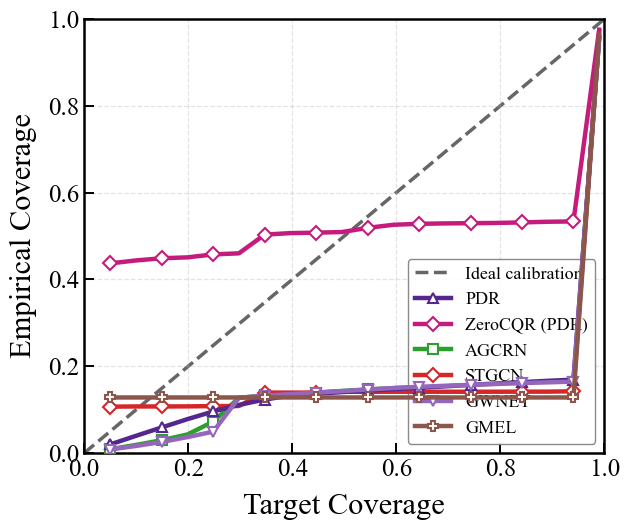

In [29]:
fig_calibration = plot_empirical_vs_target(datasets)
if SAVE_FIGURES:
    fig_calibration.savefig(FIGURE_DIR / 'empirical_vs_target_coverage.pdf', bbox_inches='tight')
plt.show()


## 2. Selective regression: MAE vs. coverage by IS score

The retained subset is formed by sorting examples from lowest to highest interval score.


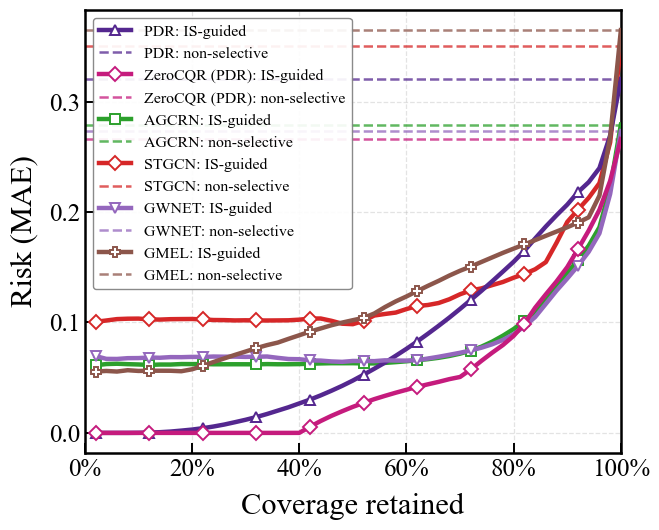

In [30]:
fig_selective = plot_selective_regression(datasets)
if SAVE_FIGURES:
    fig_selective.savefig(FIGURE_DIR / 'selective_mae_by_is.pdf', bbox_inches='tight')
plt.show()


## 3. Conditional calibration and uncertainty ranking

This figure checks calibration within interval-width strata and whether wider predicted intervals correspond to higher point-prediction error.


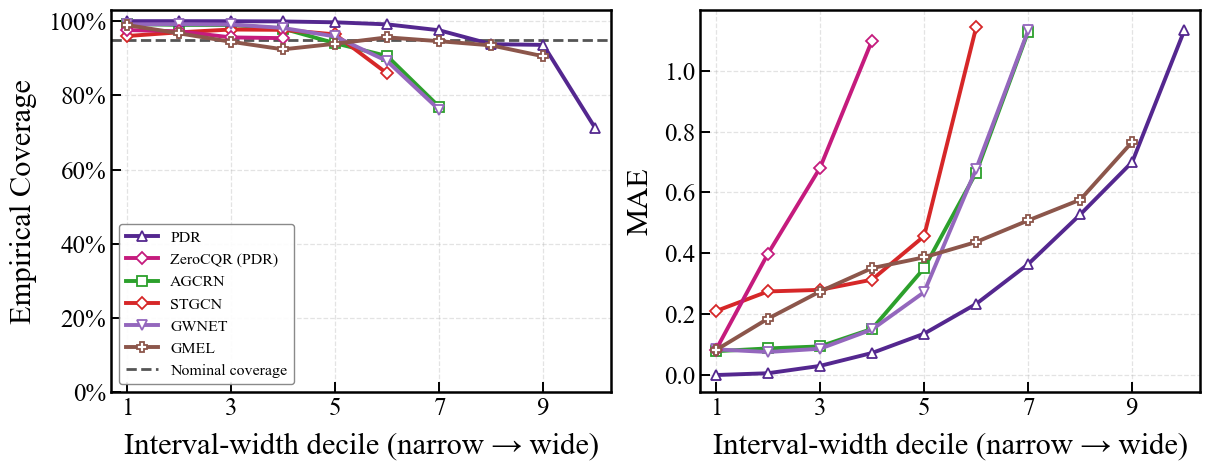

In [31]:
fig_conditional = plot_conditional_diagnostics(datasets)
if SAVE_FIGURES:
    fig_conditional.savefig(FIGURE_DIR / 'conditional_width_diagnostics.pdf', bbox_inches='tight')
plt.show()


## 4. Horizon-wise uncertainty diagnostics

Use this independently to identify forecast horizons where aggregate coverage or MAE hides degradation.


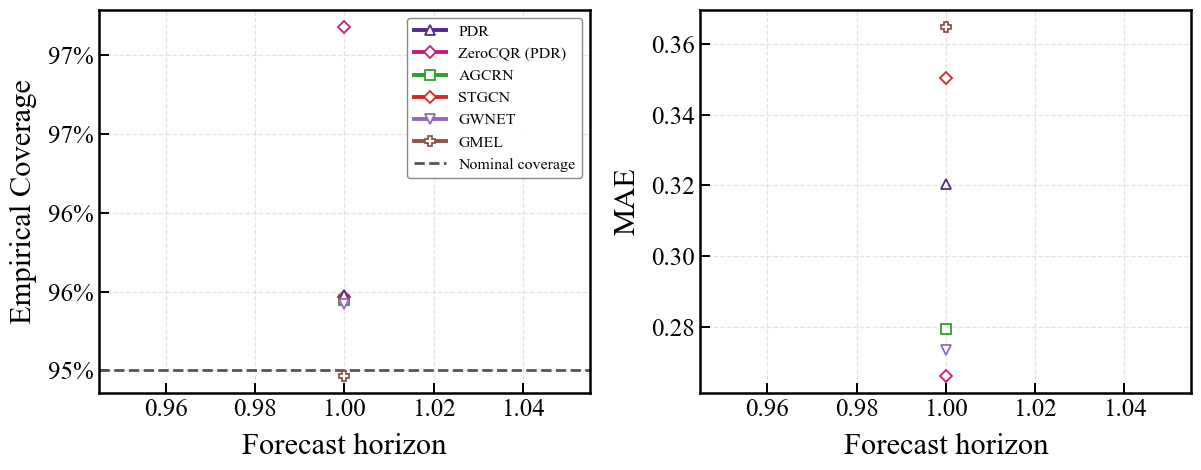

In [32]:
fig_horizon = plot_horizon_diagnostics(datasets)
if SAVE_FIGURES:
    fig_horizon.savefig(FIGURE_DIR / 'horizon_diagnostics.pdf', bbox_inches='tight')
plt.show()


## 5. Proper-score comparison: IS and CRPS

Each point is a complete held-out-set evaluation; lower-left is better on both axes. IS is the interval proper score at the exported coverage level. CRPS is computed for the uniform distribution implied by each exported interval, because the result files do not contain full predictive distributions.


,Method,IS ↓,Uniform-interval CRPS ↓
1,ZeroCQR (PDR),2.300157,0.314491
0,PDR,3.066402,0.523317
4,GWNET,3.249691,0.535685
2,AGCRN,3.259503,0.545369
3,STGCN,4.533632,0.681128
5,GMEL,5.138736,0.681120


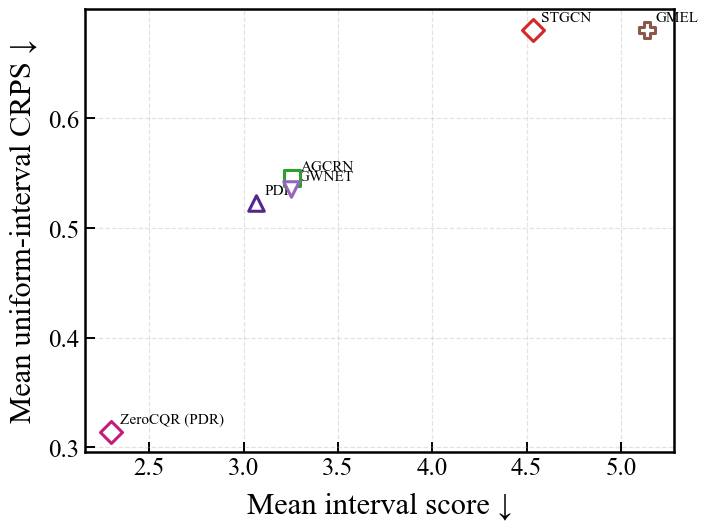

In [33]:
score_summary = pd.DataFrame([{
    'Method': d.label,
    'IS ↓': np.mean(interval_score(d.lower, d.upper, d.target)),
    'Uniform-interval CRPS ↓': np.mean(uniform_interval_crps(d.lower, d.upper, d.target)),
} for d in datasets]).sort_values('IS ↓')
display(score_summary)
fig_scores = plot_proper_score_comparison(datasets)
if SAVE_FIGURES:
    fig_scores.savefig(FIGURE_DIR / 'is_crps_comparison.pdf', bbox_inches='tight')
plt.show()


## 6. Zero-demand detection

A predicted demand of ≤0.5 is treated as zero. **True-zero recall** is the fraction of observed zero-demand OD cells identified as zero; zero F1 balances this recall with zero-label precision.


,Method,Zero F1,True-zero recall,Zero precision
1,ZeroCQR (PDR),0.913685,0.947396,0.882289
4,GWNET,0.913238,0.956430,0.873779
2,AGCRN,0.911830,0.954649,0.872687
0,PDR,0.907414,0.909580,0.905257
3,STGCN,0.887161,0.955045,0.828288
5,GMEL,0.884449,1.000000,0.792836


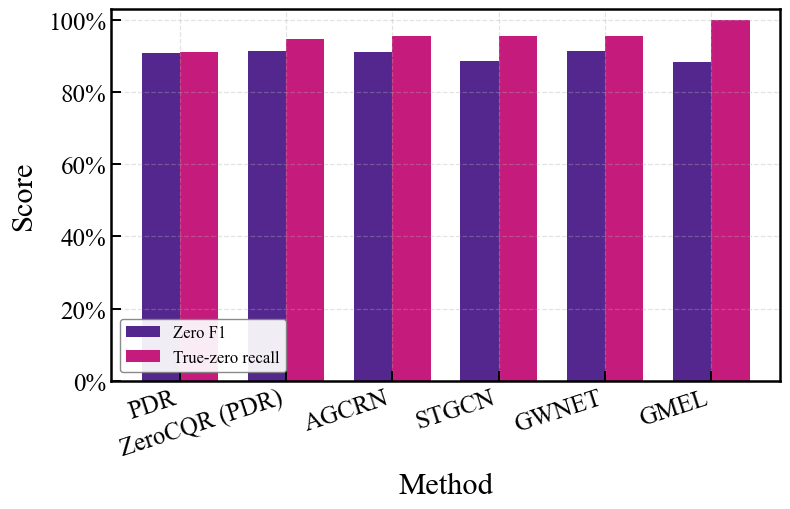

In [34]:
zero_summary = pd.DataFrame([{
    'Method': d.label,
    'Zero F1': zero_detection_metrics(d)['zero_f1'],
    'True-zero recall': zero_detection_metrics(d)['true_zero_rate'],
    'Zero precision': zero_detection_metrics(d)['zero_precision'],
} for d in datasets]).sort_values('Zero F1', ascending=False)
display(zero_summary)
fig_zero = plot_zero_detection(datasets)
if SAVE_FIGURES:
    fig_zero.savefig(FIGURE_DIR / 'zero_detection_f1_recall.pdf', bbox_inches='tight')
plt.show()


## 7. Dataset sparsity profile

This is a property of the held-out OD targets, not a model-specific selection. The left panel shows where OD cells occur; the right panel shows where demand volume occurs. Their mismatch makes the long-tail and zero inflation explicit.


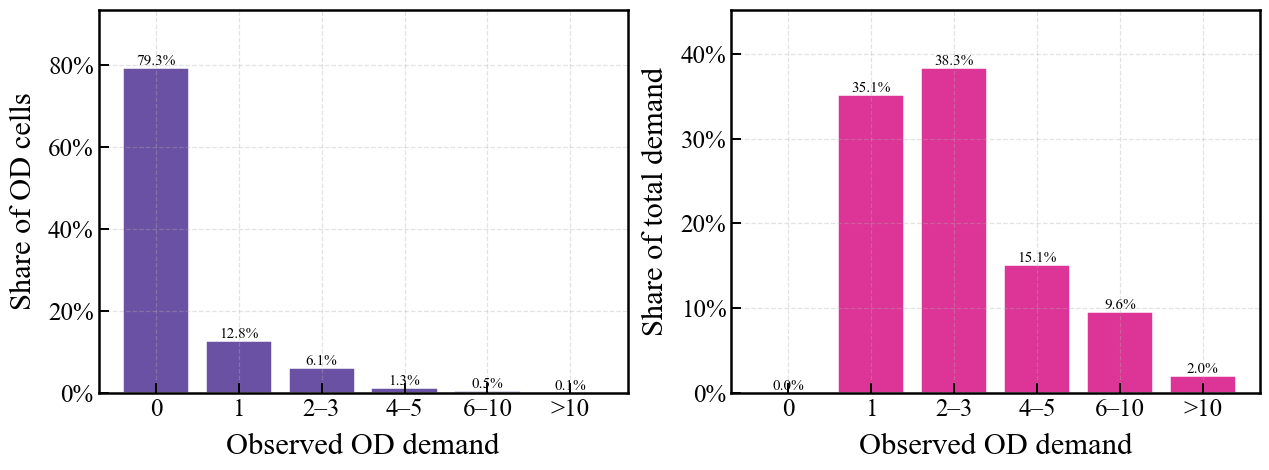

In [35]:
# The target tensors are matched across methods; use the first only to avoid duplicate work.
fig_sparsity_profile = plot_sparsity_profile(datasets[0])
if SAVE_FIGURES:
    fig_sparsity_profile.savefig(FIGURE_DIR / 'od_demand_sparsity_profile.pdf', bbox_inches='tight')
plt.show()


## 8. Sparse-OD diagnostics: zero and positive demand

Every evaluated OD cell is included once. All methods use the same fixed observed-demand strata: 0, 1, 2–3, and ≥4. The interval score jointly penalizes unnecessary width and missed targets, so lower is better. This is a direct test of whether sparse-aware calibration helps where it is intended to help.


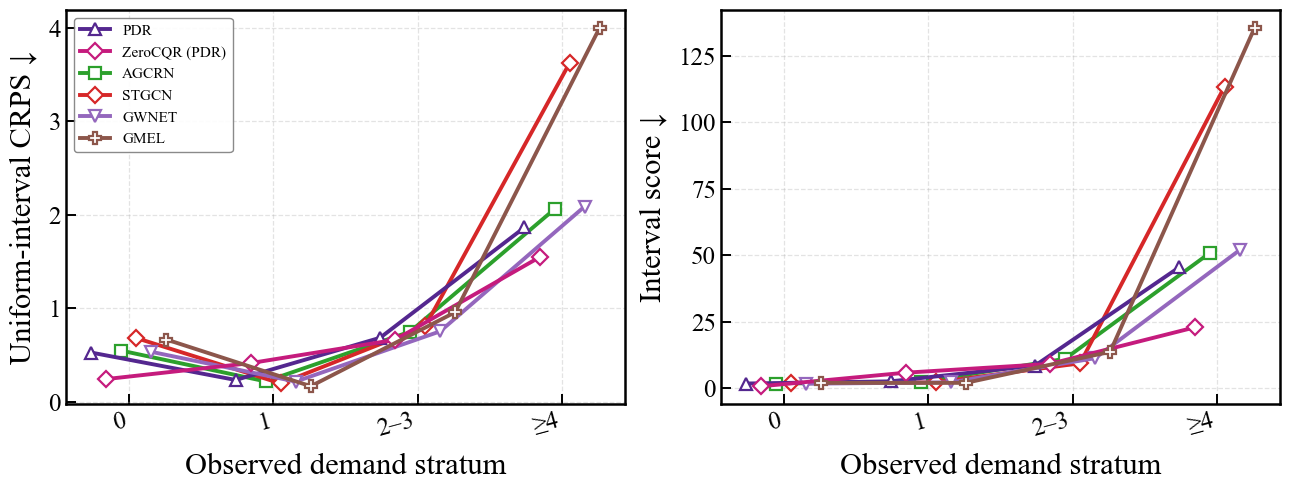

In [36]:
fig_sparse = plot_sparse_stratified_diagnostics(datasets)
if SAVE_FIGURES:
    fig_sparse.savefig(FIGURE_DIR / 'sparse_od_stratified_diagnostics.pdf', bbox_inches='tight')
plt.show()
